# 第12章：异常处理与恢复（Exception Handling and Recovery）

## 概述
- 为了在真实、多变的环境中可靠运行，AI agent 必须能够管理意外情况、错误与故障，检测问题并启动恢复或保证受控失败。
- 该模式旨在开发高度耐用与弹性的 agent，确保在面对各种异常时维持连续功能与运行完整性。
- 强调主动（proactive）与被动/响应式（reactive）策略的结合，以在复杂、不确定的环境中保持 agent 的有效性与可信度。
- 可与反思（reflection）机制配合使用：当初次尝试失败并抛出异常时，反思过程可分析失败并以改进后的方法（例如优化的 prompt）重新尝试。

## 异常处理与恢复模式概览
- 目标：使 AI agent 能够预见并管理运行时故障（如工具错误、服务不可用等），并制定缓解策略。
- 常见策略包括：
  - 错误记录（logging）
  - 重试（retries）
  - 回退/替代方案（fallbacks）
  - 优雅降级（graceful degradation）
  - 通知（notifications）
- 恢复机制包括：
  - 状态回滚（state rollback）
  - 诊断（diagnosis）
  - 自我修正（self-correction）
  - 升级/人工介入（escalation）
- 实施效果：提升可靠性与鲁棒性，使 agent 在不可预测环境中仍能继续有效运作。
- 应用示例：聊天机器人处理数据库错误、交易机器人处理金融异常、智能家居 agent 处理设备故障等。

## 关键组件（见图示）
1. 错误检测（Error Detection）
2. 错误处理（Error Handling）
3. 恢复（Recovery）
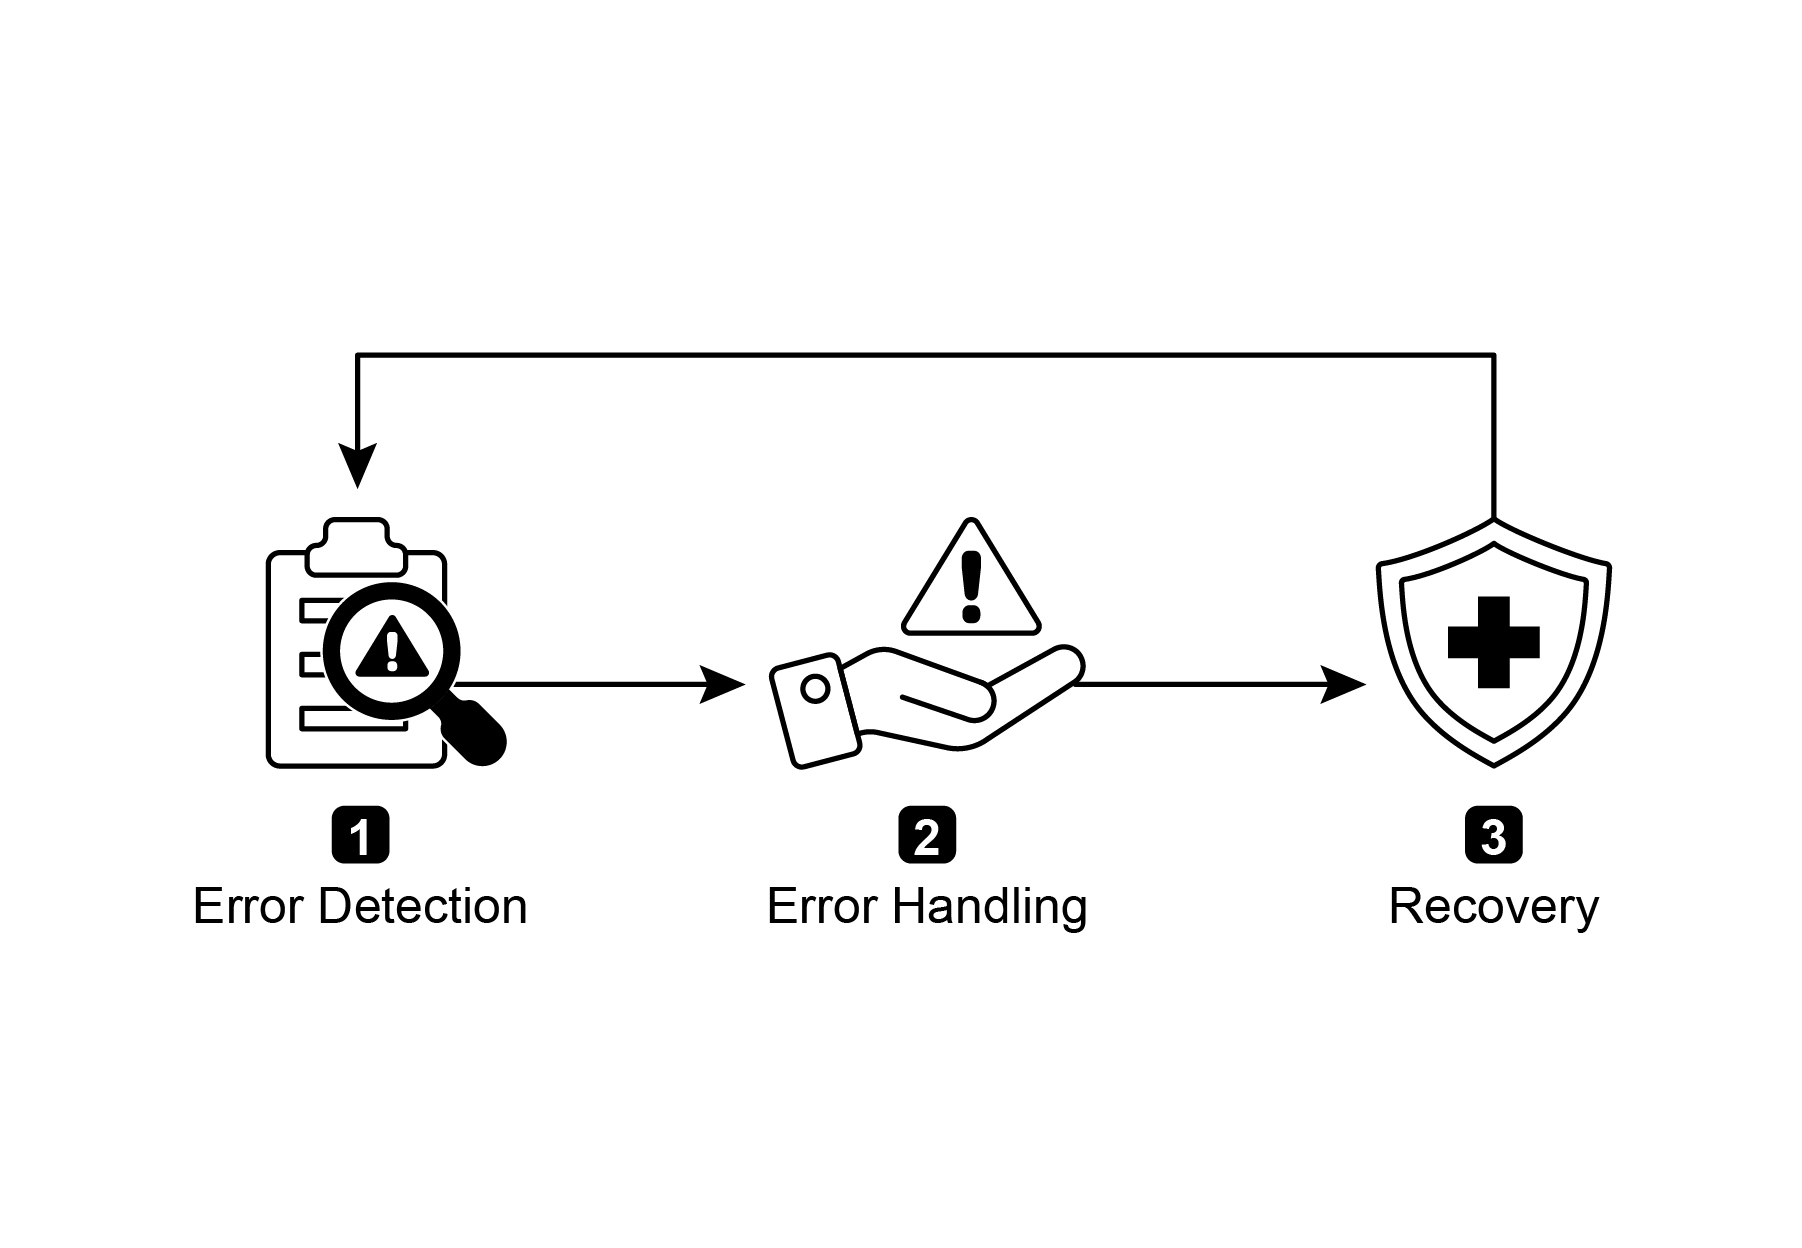
## 详细说明

### 1. 错误检测（Error Detection）
- 目标：细致识别运行中出现的异常或问题，尽早发现并捕获。
- 可能表现形式：
  - 无效或格式错误的工具输出
  - 明确的 API 错误码（如 404、500）
  - 服务/API 的异常长响应时间
  - 与预期格式不符的无意义或不连贯响应
- 检测手段：
  - 内置校验与格式检查
  - 由其他 agent 或专门监控系统进行监测（主动异常检测）
  - 指标与告警阈值（latency、错误率等）

### 2. 错误处理（Error Handling）
- 一旦检测到错误，需要有经过深思熟虑的响应计划。
- 常见措施：
  - 记录错误细节以便后续调试与分析（日志记录）
  - 重试动作或请求（可调整参数），对瞬时性错误特别有效
  - 使用替代策略或方法（回退方案），以保持部分功能
  - 优雅降级：在无法完全恢复时仍提供部分价值
  - 通知：在需要人工干预或协作时告知人工操作员或其他系统

### 3. 恢复（Recovery）
- 目标：将 agent 或系统恢复到稳定的可运行状态。
- 恢复手段：
  - 状态回滚：撤销最近更改/事务以消除错误影响
  - 深入调查错误成因，防止复发
  - 通过自我修正机制或重新规划调整 agent 的策略、逻辑或参数
  - 在复杂或严重情况下，将问题上报给人工操作员或更高层系统（升级/转交）



## 实践应用与使用场景

异常处理与恢复对于部署在真实环境中的 agent 至关重要，因为现实中无法保证完美条件。

- 客服聊天机器人（Customer Service Chatbots）
  - 场景：机器人尝试访问客户数据库，但数据库暂时不可用。
  - 要求的处理方式：
    - 不应崩溃；检测到 API 错误。
    - 通知用户暂时性问题、建议稍后重试，或将查询升级给人工客服。

- 自动化金融交易（Automated Financial Trading）
  - 场景：交易机器人尝试执行交易时遇到“资金不足”或“市场关闭”错误。
  - 要求的处理方式：
    - 记录错误，不应重复尝试同一无效交易。
    - 可能需要通知用户或调整交易策略。

- 智能家居自动化（Smart Home Automation）
  - 场景：控制智能灯的 agent 因网络或设备故障无法点亮灯。
  - 要求的处理方式：
    - 检测故障，尝试重试。
    - 若仍失败，通知用户无法打开并建议手动干预。

- 数据处理代理（Data Processing Agents）
  - 场景：批量处理文档时遇到损坏文件。
  - 要求的处理方式：
    - 跳过损坏文件并记录错误。
    - 继续处理其他文件，并在结束时报告被跳过的文件，而不是中断整个流程。

- 网络爬取代理（Web Scraping Agents）
  - 场景：爬虫遇到 CAPTCHA、网站结构变化或服务器错误（例如 404、503）。
  - 要求的处理方式：
    - 优雅地处理失败：可选择暂停、使用代理，或上报失败的具体 URL。

- 机器人与制造（Robotics and Manufacturing）
  - 场景：机械臂在装配任务中因错位无法抓取元件。
  - 要求的处理方式：
    - 通过传感器反馈检测失败，尝试重新对准并重试抓取。
    - 若持续失败，提醒人工操作员或切换到其他元件。

## 实践代码示例(ADK)

- 该实现使用 ADK 的 `SequentialAgent`，由三个子智能体按顺序组成一个分层的位置信息检索系统。
- 目标：优先获取精确位置，失败时回退到广域信息，最后汇总并向用户呈现结果。

### 二、主要组件
1. SequentialAgent
   - 负责按预定义顺序依次执行三个子智能体。
   - 确保分层检索逻辑的执行顺序与控制流。

2. 子智能体（按顺序）
   - `primary_handler`
     - 第一个被执行的智能体。
     - 尝试使用 `get_precise_location_info` 工具获取精确的位置（例如具体坐标或精确地址）。
   - `fallback_handler`
     - 作为备份智能体，当主查找失败时介入。
     - 通过检查状态变量判断主查找是否失败。
     - 从用户查询中提取城市或更宽泛的位置信息，并使用 `get_general_area_info` 工具获取一般区域信息。
   - `response_agent`
     - 序列中的最终智能体，负责查看存储在状态中的位置信息并生成对用户的最终响应。
     - 若未能找到任何位置信息，会向用户道歉并说明未取得结果。

### 三、运行流程（顺序）
1. 执行 `primary_handler`
   - 调用 `get_precise_location_info` 获取精确结果。
   - 将结果写入状态（成功或失败标记）。
2. 若主查找失败，执行 `fallback_handler`
   - 检查状态变量以确认失败。
   - 从用户查询提取城市/区域信息。
   - 调用 `get_general_area_info` 获取广域信息并写入状态。
3. 执行 `response_agent`
   - 读取状态中的位置信息（优先使用精确结果，其次使用广域结果）。
   - 向用户呈现最终结果或在无结果时道歉。

### 四、设计策略与优点
- 分层检索：先精确再回退，兼顾准确性与鲁棒性。
- 明确职责划分：每个子智能体职责单一、易于维护与扩展。
- 可扩展性：可在序列中增加更多处理器（如权限检查、缓存、日志等）。


- 该结构通过 SequentialAgent 和三个子智能体实现了可靠的分层位置检索流程，既能优先返回精确位置，又能在失败时提供合理的回退结果并最终向用户呈现清晰的响应。

In [ ]:
from google.adk.agents import Agent, SequentialAgent

## 智能体尝试主要工具。它的重点狭窄而明确。
primary_handler = Agent(
   name="primary_handler",
   model="gemini-2.0-flash-exp",
   instruction="""
您的工作是获取精确的位置信息。
使用用户提供的地址调用 get_precise_location_info 工具。
   """,
   tools=[get_precise_location_info]
)

## 智能体充当回退处理器，检查状态以决定其操作。
fallback_handler = Agent(
   name="fallback_handler",
   model="gemini-2.0-flash-exp",
   instruction="""
通过查看 state["primary_location_failed"] 来检查主要位置查找是否失败。
- 如果为 True，从用户的原始查询中提取城市并使用 get_general_area_info 工具。
- 如果为 False，什么也不做。
   """,
   tools=[get_general_area_info]
)

## 智能体从状态中呈现最终结果。
response_agent = Agent(
   name="response_agent",
   model="gemini-2.0-flash-exp",
   instruction="""
查看存储在 state["location_result"] 中的位置信息。
向用户清晰简洁地呈现此信息。
如果 state["location_result"] 不存在或为空，请道歉您无法检索位置。
   """,
   tools=[]  # 此智能体根据最终状态进行推理。
)

## SequentialAgent 确保处理器按保证的顺序运行。
robust_location_agent = SequentialAgent(
   name="robust_location_agent",
   sub_agents=[primary_handler, fallback_handler, response_agent]
)

In [1]:
import datasurfer as ds 

In [2]:
agent_dummy = ds.agent(name='Tom', tools='none', skills='none')
agent_search = ds.agent(name='Jerry', tools=['web_search', 'get_current_datetime'], skills='none')
agent_controller = ds.agent(subagents=[agent_dummy, agent_search], name='Alice', tools='none', skills='none')


In [3]:
prompt = '''
你必须执行以下步骤完成任务
1. 让agent Tom查询德国明天的天气情况
2. 如果Tom查询失败了，使用agent Jerry查询德国明天的天气情况
3. 将查询结果返回给用户
'''



In [4]:
agent_controller.resp(prompt)

Alice (Assistant):

    Reasoning:
    用户要求我完成一个任务：查询德国明天的天气情况。根据步骤，我需要先让Tom查询，如果失败再让Jerry查询。

    让我先尝试让Tom查询德国明天的天气情况。

    Function Call:
        Name: delegate_task
        Arguments: {"agent_name":"Tom","task":"请查询德国明天的天气情况"}
        Call ID: call_270557019510000


--------------------------------------------------------------------------------------------------------

Tom (Assistant):

    Reasoning:
    1.  **Identify the User's Request:** The user is asking for the weather forecast in
    Germany for tomorrow.

    2.  **Analyze the Constraints & Capabilities:**
        *   I am an AI language model, not a real-time data source or a web browser with live access
    to current weather APIs (like OpenWeatherMap, WeatherAPI, etc.).
        *   My knowledge cutoff is up to my last training update, which means I cannot provide
    *real-time* or *tomorrow's* specific weather conditions.

    3.  **Formulate the Response:**
        *   Acknowledge the request politely.
        *   Cl

'根据任务要求，我已完成以下步骤：\n\n1. **让Tom查询德国明天的天气** → Tom无法提供实时天气信息，建议用户访问德国气象局（DWD）官网或主流天气预报网站获取准确数据。\n\n2. **由于Tom失败，使用Jerry查询** → Jerry成功查询到了德国的天气预报结果。\n\n3. **将查询结果返回给用户**：\n\n---\n\n## 🌤️ 德国明天天气预报\n\n| 项目 | 数据 |\n|------|------|\n| **天气状况** | 部分多云/晴间多云 (Teilweise sonnig) |\n| **最高气温** | 约 28°C |\n| **最低气温** | 约 16°C |\n\n### 📅 未来几天天气趋势：\n- **今天（6月21日）**：有轻微降雨，气温27°C/17°C\n- **明天（6月22日）**：部分多云，气温28°C/16°C ⭐\n- **后天（6月23日）**：晴朗，气温28°C/16°C\n- **6月24日**：晴朗，气温28°C/16°C\n\n### 🌡️ 其他天气信息：\n- **气压**：1025 hPa（缓慢上升）\n- **空气质量指数 (AQI)**：46（良好）\n- **紫外线指数**：7（较高）\n\n### 💡 出行建议：\n明天德国大部分地区天气晴朗，气温适宜，适合户外活动。但由于紫外线指数较高，外出时请注意防晒措施。\n\n如需查询特定城市或地区的详细天气预报，请告诉我！'

## 总结

### 什么（What）
- 在真实世界环境中运行的 AI agent 必然会遇到意外情形、错误和系统故障。
- 这些中断可能包括：
  - 工具故障
  - 网络问题
  - 无效或异常数据
- 这些问题会威胁 agent 完成任务的能力。
- 如果没有结构化的管理方式，agent 容易变得脆弱、不可靠，并在遇到意外阻碍时可能完全失败。
- 这种不可靠性使得在关键或复杂应用中难以部署 agent，而这些场景通常要求稳定一致的性能。

### 为什么采用该模式（Why）
- “异常处理与恢复（Exception Handling and Recovery）”模式为构建健壮、具弹性的 AI agent 提供了标准化解决方案。
- 它赋予 agent 预期、管理和从运行故障中恢复的能力，主要包含：
  - 主动的错误检测
    - 例如监控工具输出和 API 响应
  - 被动/反应式的处理策略
    - 记录日志以供诊断
    - 对短暂性故障进行重试
    - 使用后备（fallback）机制
  - 针对更严重问题的恢复协议
    - 回滚至稳定状态
    - 通过调整计划进行自我修正
    - 将问题上报/升级给人工操作员
- 该系统化方法能确保 agent：
  - 保持运行完整性
  - 从故障中学习
  - 在不可预测环境中可靠地执行任务

### 经验法则（Rule of thumb）
- 在任何部署于动态真实环境的 AI agent 中应使用此模式，尤其当存在：
  - 系统故障
  - 工具错误
  - 网络问题
  - 或不可预测的输入
- 当操作可靠性为关键需求时，应优先采用该模式。
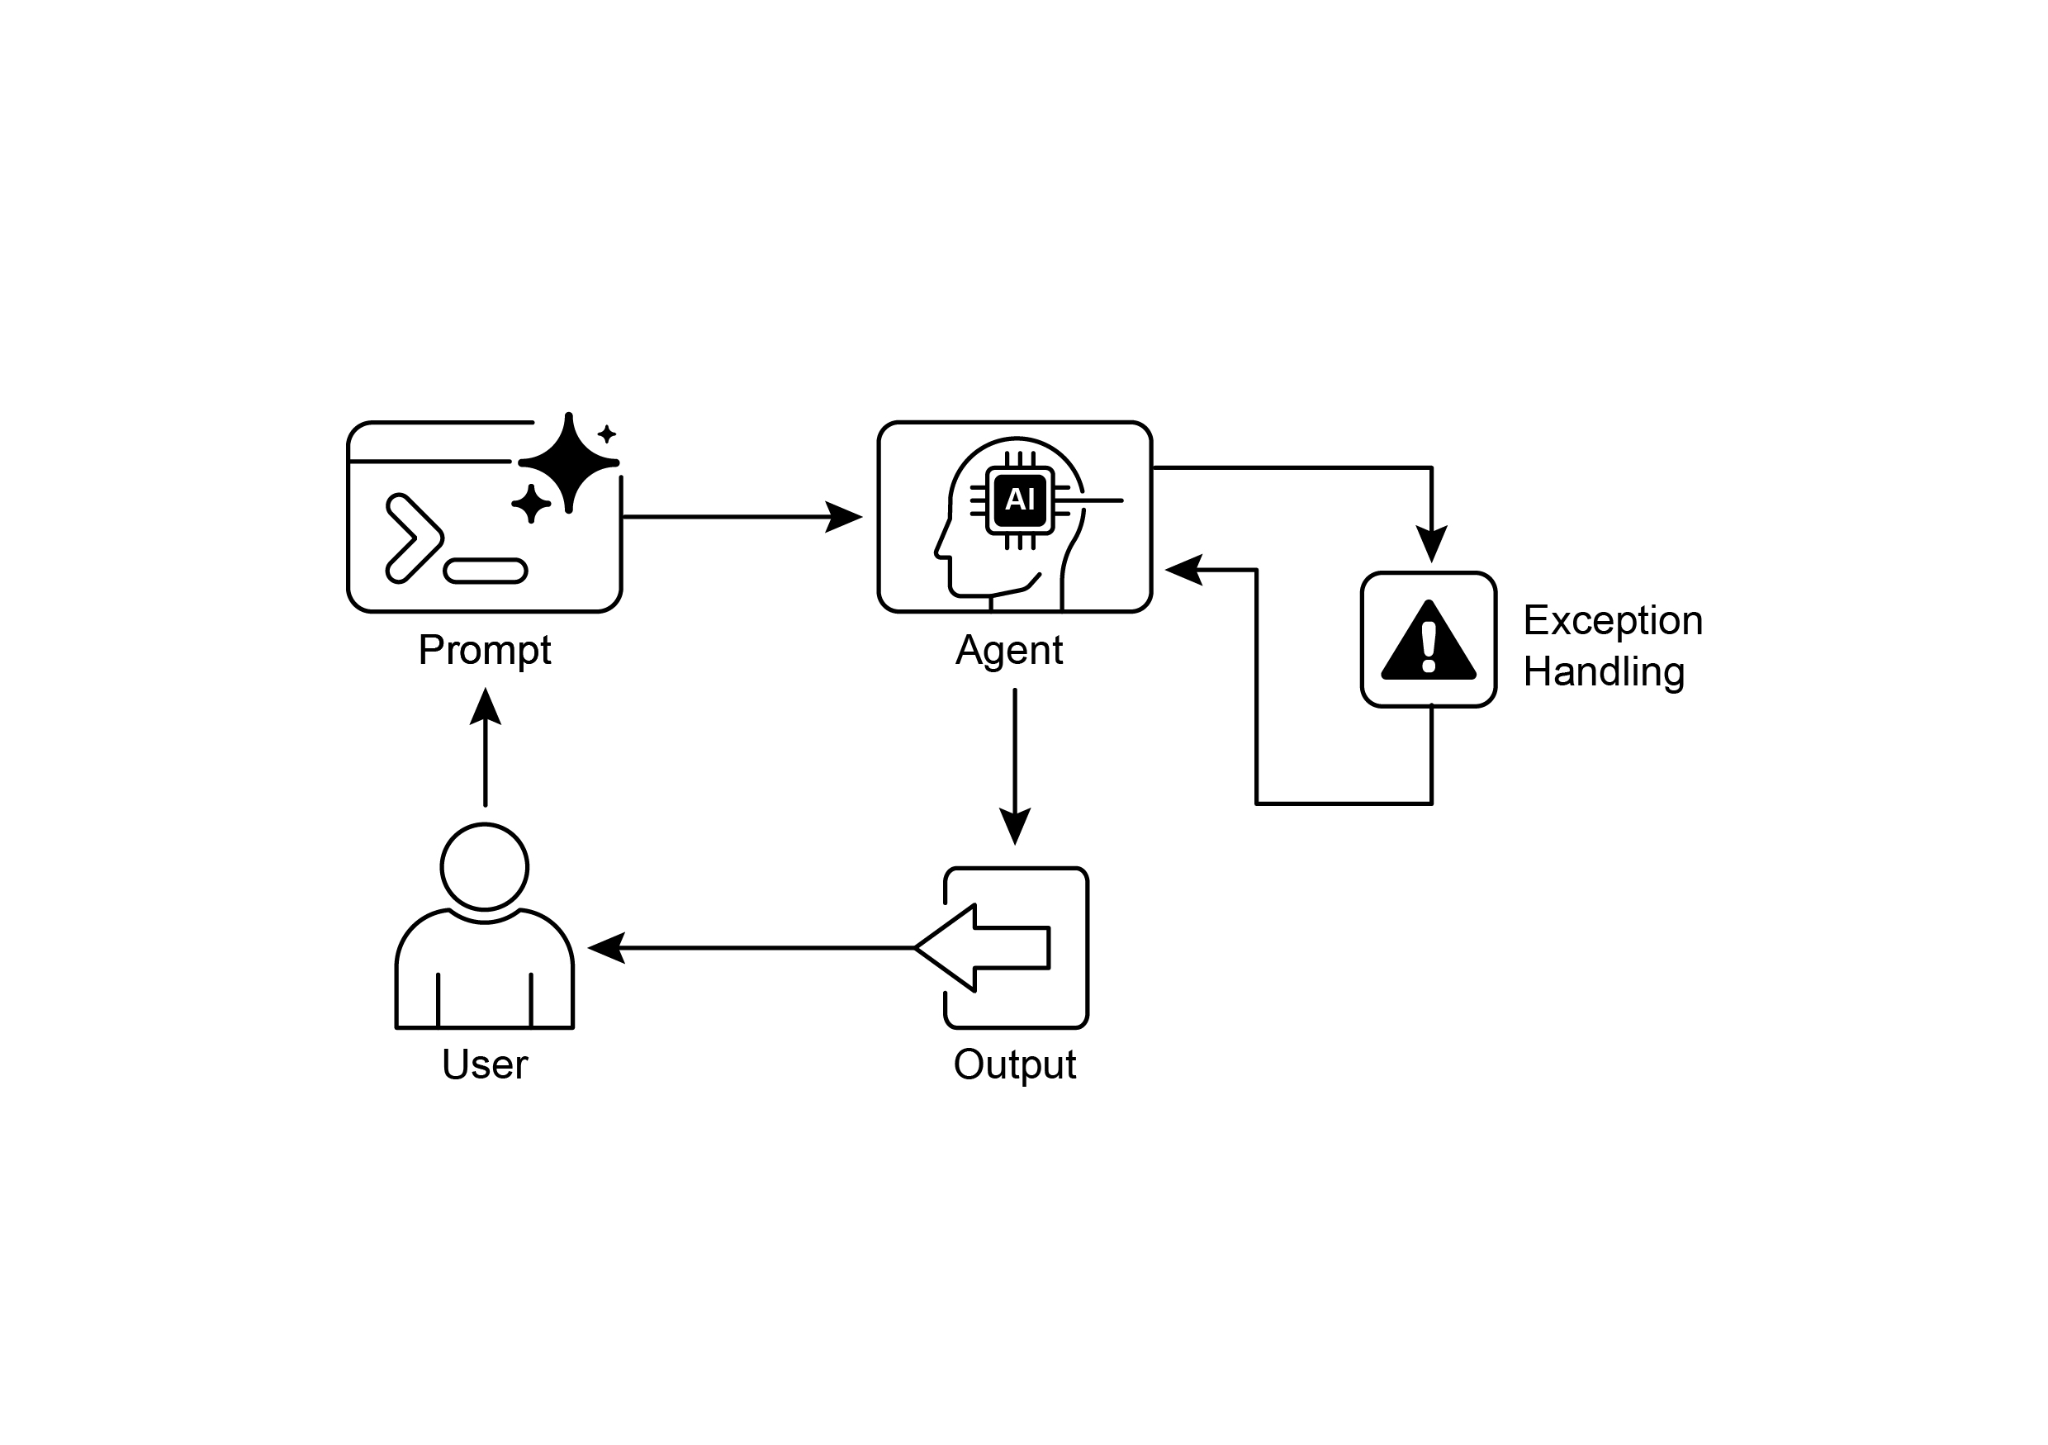

